In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scp
import joblib

from wordcloud import WordCloud
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn import tree
from google.colab import drive
from google.colab import files
from time import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import LabelEncoder, Normalizer, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,  roc_auc_score

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pth = '/content/drive/MyDrive/projek data analis/'

In [4]:
df = pd.read_csv(pth+'diabetes_prediction_dataset.csv')
print(df.shape)
df.head()

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
#Untuk mengubah data baris menjadi kolom
display(df.describe(include=np.number).transpose())
display(df.describe(include=object).transpose())

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


,count,unique,top,freq
gender,100000,3,Female,58552
smoking_history,100000,6,No Info,35816


In [8]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [9]:
# Replace 'other' with NaN
df.loc[df['gender'].str.strip().str.lower() == 'other', 'gender'] = np.nan

# Display the DataFrame after replacement
print("\nDataFrame after replacing 'other' with NaN:")
print(df)


DataFrame after replacing 'other' with NaN:
       gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0 

In [10]:

#Cek duplikasi data
df.duplicated(keep=False).sum()

6939

In [11]:
#Menghapus duplikat
df2= df.drop_duplicates(keep=False)

In [12]:
#Cek duplikasi data
df2.duplicated(keep=False).sum()

0

In [13]:
#cek missung value
def cek_null(df):
  col_na = df.isnull().sum().sort_values(ascending=False)
  percent = col_na / len(df)

  missing_data = pd.concat([col_na, percent], axis=1, keys=['Total', 'Percent'])
  print(missing_data[missing_data['Total'] > 0])

In [14]:
#Untuk menampilkan hasil dari functuation
cek_null(df)

        Total  Percent
gender     18  0.00018


In [15]:
#Melakukan imputasi missing value dengan nilai modus
#Langkah 1
modus = df['gender'].mode()[0]
print(modus)

#Langkah 2
df['gender'] = df['gender'].fillna(modus)

#Langkah 3
df['gender'].isna().sum()

Female


0

In [16]:
cek_null(df)

Empty DataFrame
Columns: [Total, Percent]
Index: []


In [17]:
#Remove data outlier
idx = df[df['diabetes'] > 500].index
df = df.drop(idx, axis=0)

In [18]:
df.shape

(100000, 9)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


#Visualisasi

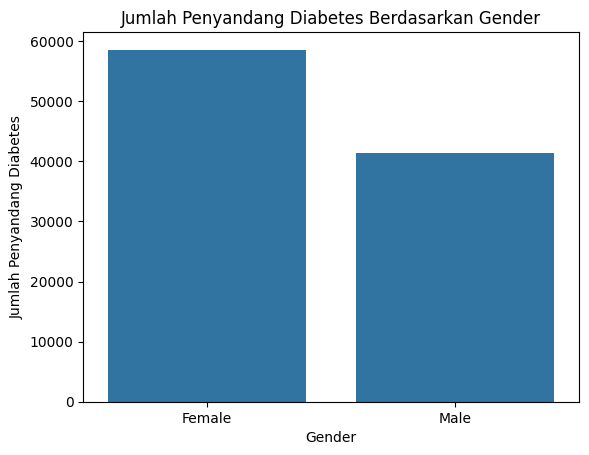

In [20]:
sns.countplot(x='gender', data=df) #nama attribut dalam dataset
plt.title('Jumlah Penyandang Diabetes Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah Penyandang Diabetes')
plt.show()

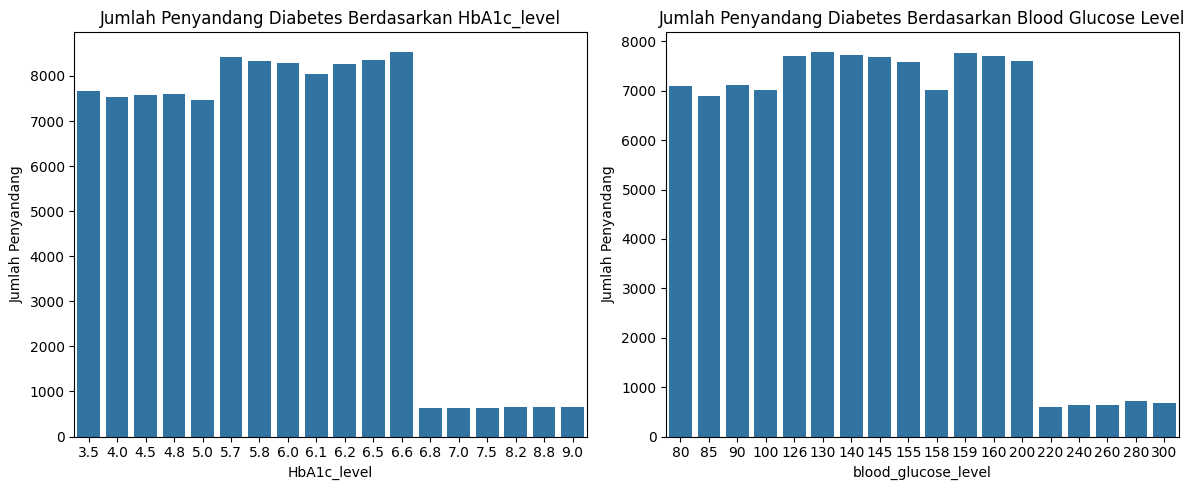

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot pertama: HbA1c_level
sns.countplot(x='HbA1c_level', data=df, ax=axes[0])
axes[0].set_title('Jumlah Penyandang Diabetes Berdasarkan HbA1c_level')
axes[0].set_xlabel('HbA1c_level')
axes[0].set_ylabel('Jumlah Penyandang')

# Plot kedua: blood_glucose_level
sns.countplot(x='blood_glucose_level', data=df, ax=axes[1])
axes[1].set_title('Jumlah Penyandang Diabetes Berdasarkan Blood Glucose Level')
axes[1].set_xlabel('blood_glucose_level')
axes[1].set_ylabel('Jumlah Penyandang')

plt.tight_layout()
plt.show()

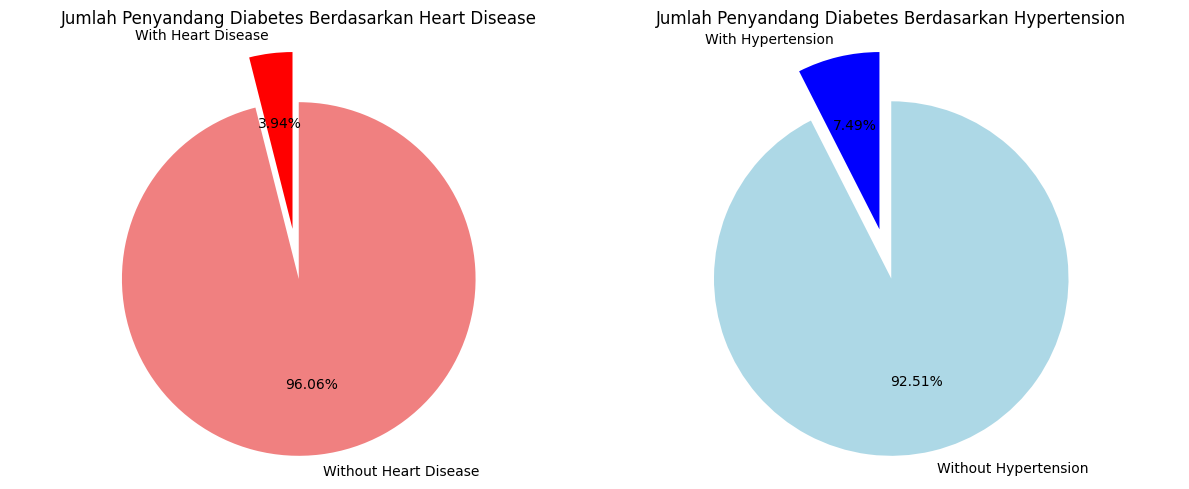

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heart Disease
heart_disease_counts = df['heart_disease'].value_counts()
labels_hd = ['With Heart Disease', 'Without Heart Disease']
sizes_hd = [heart_disease_counts[1], heart_disease_counts[0]]
axes[0].pie(sizes_hd, labels=labels_hd, autopct='%1.2f%%', explode=[0.1, 0.1],
            colors=['red', 'lightcoral'], startangle=90, radius=0.7)
axes[0].set_title('Jumlah Penyandang Diabetes Berdasarkan Heart Disease')
axes[0].axis('equal')

# Hypertension
hypertension_counts = df['hypertension'].value_counts()
labels_ht = ['With Hypertension', 'Without Hypertension']
sizes_ht = [hypertension_counts[1], hypertension_counts[0]]
axes[1].pie(sizes_ht, labels=labels_ht, autopct='%1.2f%%', explode=[0.1, 0.1],
            colors=['blue', 'lightblue'], startangle=90, radius=0.7)
axes[1].set_title('Jumlah Penyandang Diabetes Berdasarkan Hypertension')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

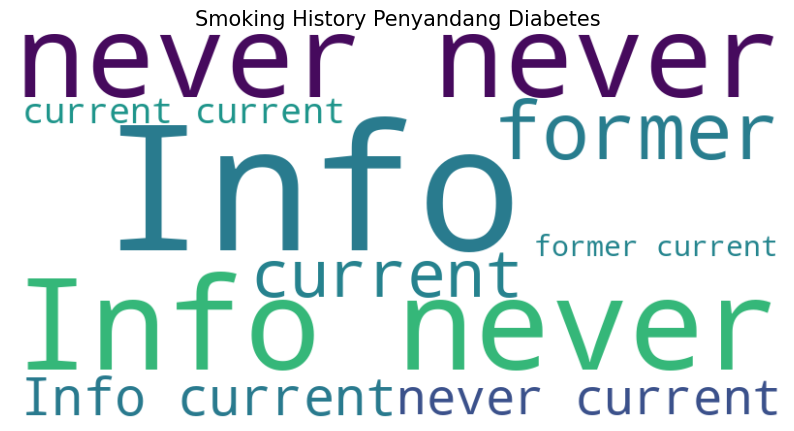

In [23]:
# Menggabungkan semua nama menjadi satu teks
text = ' '.join(df['smoking_history'].tolist())

# Membuat Worldcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

#Menampilkan worldcloud
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Smoking History Penyandang Diabetes', fontsize=15)
plt.show()

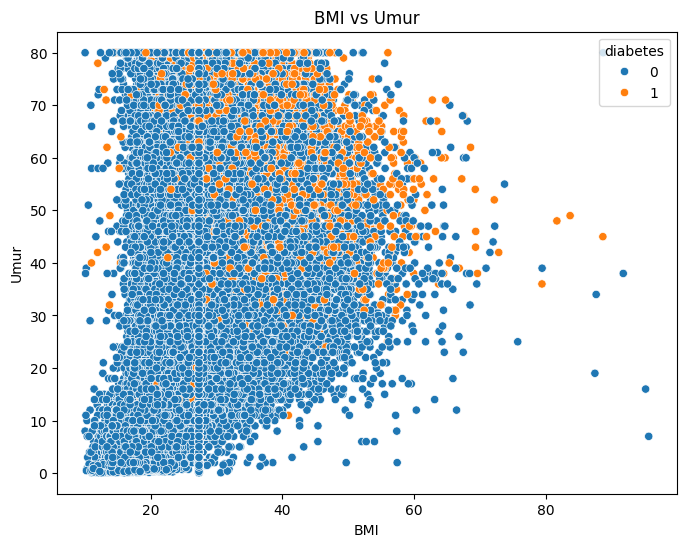

In [24]:
# Membuat scatter plot untuk 'bmi' vs 'diabetes'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='bmi', y='age', hue='diabetes', data=df)

plt.title('BMI vs Umur')
plt.xlabel('BMI')
plt.ylabel('Umur')

# Menampilkan plot
plt.show()

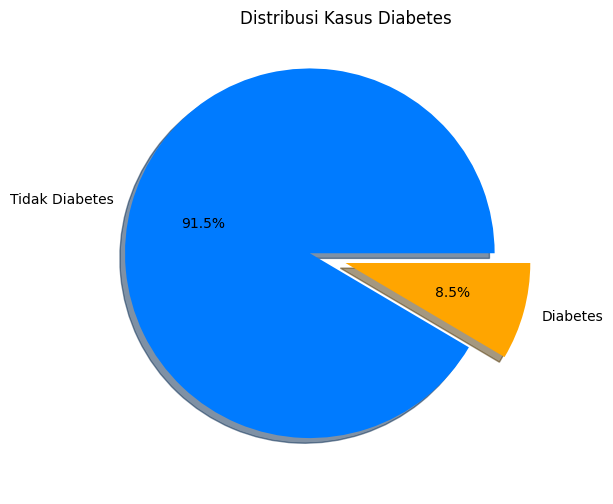

In [25]:
# Hitung jumlah kasus diabetes (0 = Tidak, 1 = Ya)
diabetes_counts = df['diabetes'].value_counts()

# Definisikan label agar lebih jelas
labels = ["Tidak Diabetes", "Diabetes"] if len(diabetes_counts) > 1 else ["Diabetes"]

# Atur efek explode untuk memisahkan potongan pie pertama jika ada lebih dari satu kategori
explode = (0.2, 0) if len(diabetes_counts) > 1 else (0,)

# Membuat figure dengan ukuran 8x6 inch
plt.figure(figsize=(8, 6))

# Membuat pie chart untuk distribusi stroke:
diabetes_counts.plot(kind='pie',
                   autopct='%1.1f%%',  # Menampilkan persentase
                   startangle=0,       # Sudut awal pie chart
                   colors=['#007BFF', '#FFA500'],  # Warna slice
                   shadow=True,        # Efek bayangan
                   explode=explode,    # Pisahkan bagian pertama
                   labels=labels)      # Tambahkan label untuk kategori

# Menambahkan judul grafik
plt.title('Distribusi Kasus Diabetes')

# Menghilangkan label sumbu y agar lebih rapi
plt.ylabel('')

# Menampilkan plot
plt.show()

#Pra-Processing

In [26]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])

In [27]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  int64  
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  int64  
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.9 MB


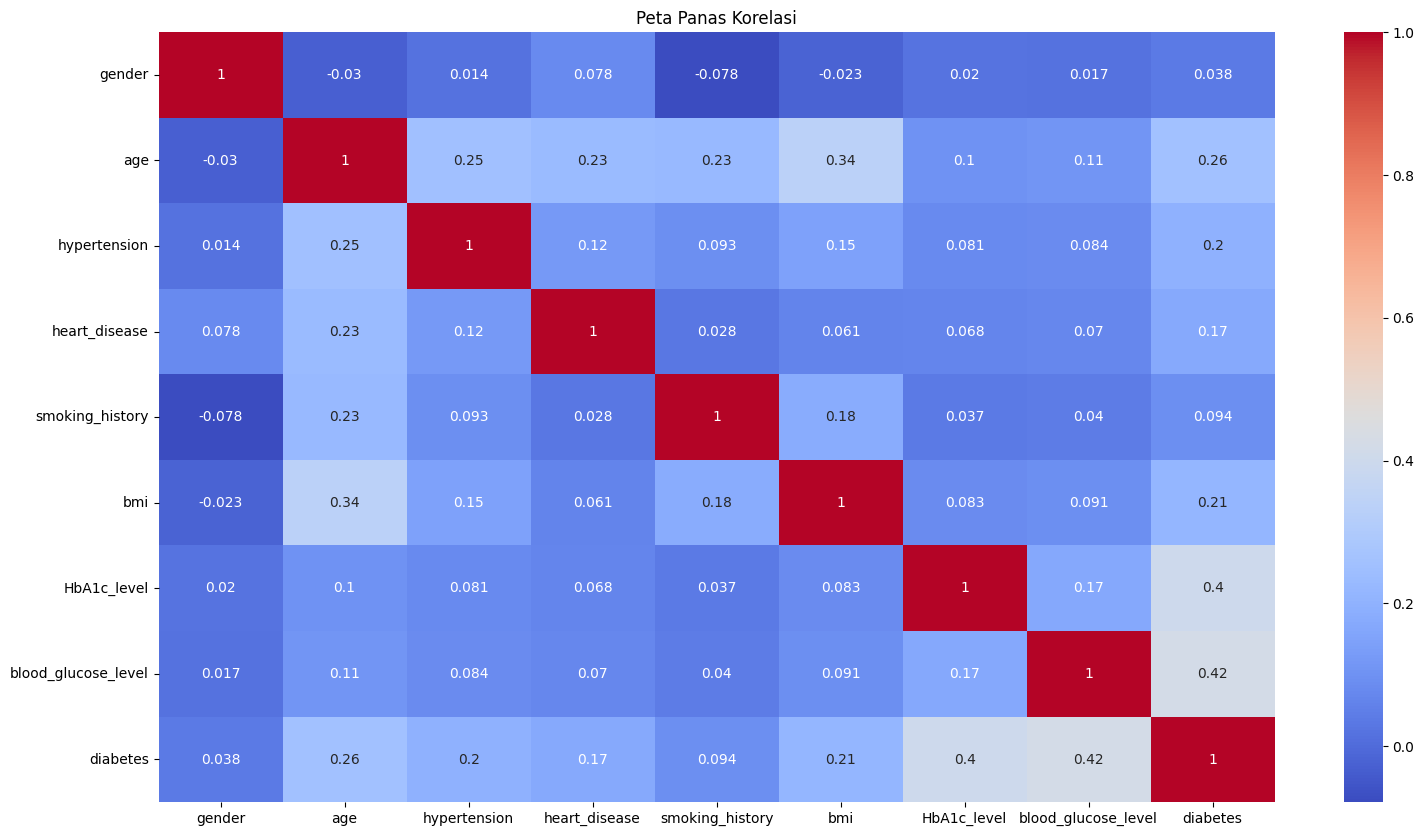

In [29]:
# Membuat visualisasi peta panas (heatmap) untuk melihat korelasi antar variabel numerik

# Memilih kolom-kolom yang bertipe numerik (integer dan float) dari dataframe
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns

# Membuat figure dengan ukuran 18x10 inci
plt.figure(figsize=(18, 10))

# Membuat peta panas menggunakan seaborn:
# - df[kolom_numerik].corr() menghitung korelasi antar kolom numerik
# - annot=True menampilkan nilai korelasi di setiap sel
# - cmap='coolwarm' mengatur skema warna (merah=korelasi positif, biru=korelasi negatif)
sns.heatmap(df[kolom_numerik].corr(), annot=True, cmap='coolwarm')

# Menambahkan judul pada plot
plt.title('Peta Panas Korelasi')

# Menampilkan visualisasi
plt.show()

#Split Data

In [ ]:
# Definisi fitur dan label
X = df.drop(['diabetes'], axis=1)
y = df['diabetes']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (80000, 8)
Test size: (20000, 8)


#Model

##RandomForest

In [ ]:
import time

# Hyperparameter tuning for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid_rf, cv=5, scoring='f1_weighted')
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_

# Train final model with best hyperparameters
st = time.time()
best_rf.fit(X_train, y_train)
print("[DONE] training process finished:", time.time()-st, "second(s)\n")

# Evaluasi model terbaik RandomForestClassifier
y_pred_rf = best_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

# Calculate AUC for Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_rf)

# Print hasil evaluasi
print("Best RandomForestClassifier Accuracy:", accuracy_rf)
print("Best Hyperparameters for RandomForestClassifier:", grid_search_rf.best_params_)
print("\n=== Evaluation Metrics ===")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Print Classification Report dan Confusion Matrix
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_rf, zero_division=1))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_rf))

[DONE] training process finished: 3.5004830360412598 second(s)

Best RandomForestClassifier Accuracy: 0.97225
Best Hyperparameters for RandomForestClassifier: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

=== Evaluation Metrics ===
Accuracy: 0.9722
Precision: 0.9731
Recall: 0.9722
F1-score: 0.9698
AUC: 0.9717

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18292
           1       1.00      0.68      0.81      1708

    accuracy                           0.97     20000
   macro avg       0.99      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000


=== Confusion Matrix ===
[[18292     0]
 [  555  1153]]


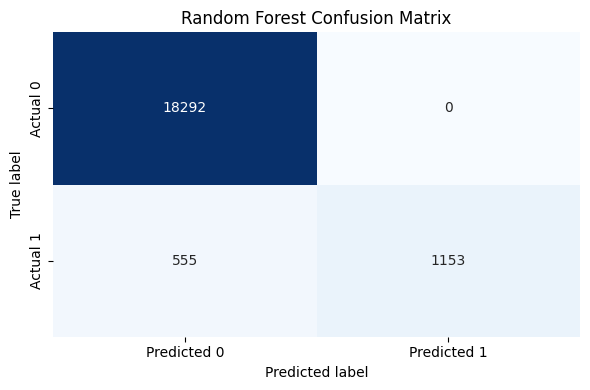

In [ ]:
# Contoh matriks kebingungan (ganti dengan yang sesuai)
rf_cm = confusion_matrix(y_test, y_pred_rf)

# Plotting confusion matrix heatmap for Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

##KNN

In [ ]:
import time

# Hyperparameter tuning for KNeighborsClassifier
param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid_knn, cv=5, scoring='f1_weighted')
grid_search_knn.fit(X_train, y_train)
best_knn = grid_search_knn.best_estimator_

# Train final model with best hyperparameters
st = time.time()
best_knn.fit(X_train, y_train)
print("[DONE] training process finished:", time.time()-st, "second(s)\n")

# Evaluasi model terbaik KNeighborsClassifier
y_pred_knn = best_knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn, average='weighted')
recall = recall_score(y_test, y_pred_knn, average='weighted')
f1 = f1_score(y_test, y_pred_knn, average='weighted')

# Calculate AUC for KNN (only for binary classification)
y_prob_knn = best_knn.predict_proba(X_test)[:, 1] if len(set(y_test)) == 2 else None
auc = roc_auc_score(y_test, y_prob_knn) if y_prob_knn is not None else "N/A"

# Print hasil evaluasi
print("Best KNeighborsClassifier Accuracy:", accuracy_knn)
print("Best Hyperparameters for KNeighborsClassifier:", grid_search_knn.best_params_)
print("\n=== Evaluation Metrics ===")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc}")

# Print Classification Report dan Confusion Matrix
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_knn, zero_division=1))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_knn))

[DONE] training process finished: 0.16661739349365234 second(s)

Best KNeighborsClassifier Accuracy: 0.9525
Best Hyperparameters for KNeighborsClassifier: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

=== Evaluation Metrics ===
Accuracy: 0.9525
Precision: 0.9496
Recall: 0.9525
F1-score: 0.9469
AUC: 0.8740047606586056

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     18292
           1       0.87      0.52      0.65      1708

    accuracy                           0.95     20000
   macro avg       0.91      0.76      0.81     20000
weighted avg       0.95      0.95      0.95     20000


=== Confusion Matrix ===
[[18161   131]
 [  819   889]]


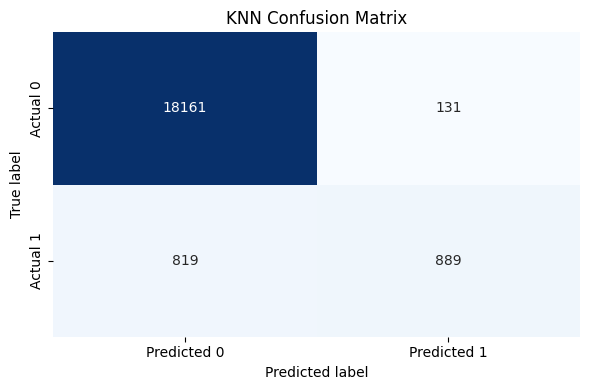

In [ ]:
# Contoh matriks kebingungan (ganti dengan yang sesuai)
knn_cm = confusion_matrix(y_test, y_pred_knn)

# Plotting confusion matrix heatmap for KNN
plt.figure(figsize=(6, 4))
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

##DecisionTree

In [ ]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for DecisionTreeClassifier
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid_dt, cv=5, scoring='f1_weighted')
grid_search_dt.fit(X_train, y_train)
best_dt = grid_search_dt.best_estimator_

# Train final model with best hyperparameters
st = time.time()
best_dt.fit(X_train, y_train)
print("[DONE] training process finished:", time.time()-st, "second(s)\n")

# Evaluasi model terbaik DecisionTreeClassifier
y_pred_dt = best_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt, average='weighted')
recall = recall_score(y_test, y_pred_dt, average='weighted')
f1 = f1_score(y_test, y_pred_dt, average='weighted')

# Calculate AUC for Decision Tree (only for binary classification)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1] if len(set(y_test)) == 2 else None
auc = roc_auc_score(y_test, y_prob_dt) if y_prob_dt is not None else "N/A"

# Print hasil evaluasi
print("Best DecisionTreeClassifier Accuracy:", accuracy_dt)
print("Best Hyperparameters for DecisionTreeClassifier:", grid_search_dt.best_params_)
print("\n=== Evaluation Metrics ===")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc}")

# Print Classification Report dan Confusion Matrix
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_dt, zero_division=1))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_dt))


[DONE] training process finished: 0.10163378715515137 second(s)

Best DecisionTreeClassifier Accuracy: 0.972
Best Hyperparameters for DecisionTreeClassifier: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}

=== Evaluation Metrics ===
Accuracy: 0.9720
Precision: 0.9724
Recall: 0.9720
F1-score: 0.9697
AUC: 0.9738510897381074

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.99      0.68      0.81      1708

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000


=== Confusion Matrix ===
[[18275    17]
 [  543  1165]]


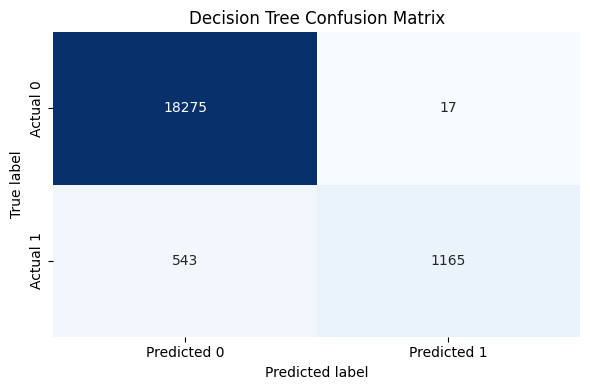

In [ ]:
# Menghitung matriks kebingungan
dt_cm = confusion_matrix(y_test, y_pred_dt)

# Plotting confusion matrix heatmap untuk Decision Tree
plt.figure(figsize=(6, 4))
sns.heatmap(dt_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

##NaiveBayes

In [ ]:
import time
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Train final model using Gaussian Naive Bayes
best_nb = GaussianNB()
st = time.time()
best_nb.fit(X_train, y_train)
print("[DONE] training process finished:", time.time()-st, "second(s)\n")

# Evaluasi model terbaik Naive Bayes
y_pred_nb = best_nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb, average='weighted')
recall = recall_score(y_test, y_pred_nb, average='weighted')
f1 = f1_score(y_test, y_pred_nb, average='weighted')

# Calculate AUC for Naive Bayes (only for binary classification)
y_prob_nb = best_nb.predict_proba(X_test)[:, 1] if len(set(y_test)) == 2 else None
auc = roc_auc_score(y_test, y_prob_nb) if y_prob_nb is not None else "N/A"

# Print hasil evaluasi
print("Best GaussianNB Accuracy:", accuracy_nb)
print("\n=== Evaluation Metrics ===")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc}")

# Print Classification Report dan Confusion Matrix
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_nb, zero_division=1))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_nb))


[DONE] training process finished: 0.019074440002441406 second(s)

Best GaussianNB Accuracy: 0.90475

=== Evaluation Metrics ===
Accuracy: 0.9048
Precision: 0.9217
Recall: 0.9048
F1-score: 0.9117
AUC: 0.9233705876463573

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     18292
           1       0.46      0.64      0.53      1708

    accuracy                           0.90     20000
   macro avg       0.71      0.78      0.74     20000
weighted avg       0.92      0.90      0.91     20000


=== Confusion Matrix ===
[[17005  1287]
 [  618  1090]]


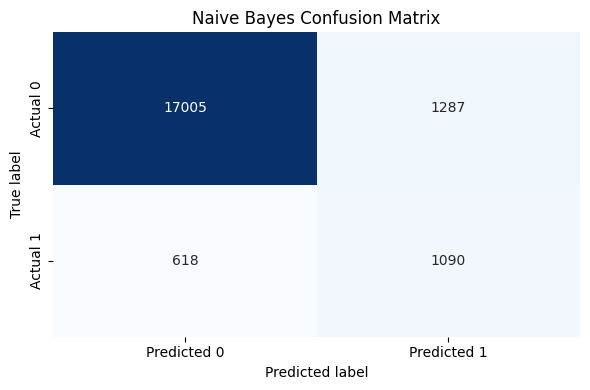

In [ ]:
# Menghitung matriks kebingungan
nb_cm_multinomial = confusion_matrix(y_test, y_pred_nb)

# Plotting confusion matrix heatmap untuk Naive Bayes
plt.figure(figsize=(6, 4))
sns.heatmap(nb_cm_multinomial, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

##Logistic Regression

In [ ]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Logistic Regression
param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search_lr = GridSearchCV(estimator=LogisticRegression(random_state=42), param_grid=param_grid_lr, cv=5, scoring='f1_weighted')
grid_search_lr.fit(X_train, y_train)
best_lr = grid_search_lr.best_estimator_

# Train final model with best hyperparameters
st = time.time()
best_lr.fit(X_train, y_train)
print("[DONE] training process finished:", time.time()-st, "second(s)\n")

# Evaluasi model terbaik Logistic Regression
y_pred_lr = best_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

# Calculate AUC for Logistic Regression (only for binary classification)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1] if len(set(y_test)) == 2 else None
auc = roc_auc_score(y_test, y_prob_lr) if y_prob_lr is not None else "N/A"

# Print hasil evaluasi
print("Best LogisticRegression Accuracy:", accuracy_lr)
print("Best Hyperparameters for LogisticRegression:", grid_search_lr.best_params_)
print("\n=== Evaluation Metrics ===")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc}")

# Print Classification Report dan Confusion Matrix
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_lr, zero_division=1))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_lr))


[DONE] training process finished: 0.39403200149536133 second(s)

Best LogisticRegression Accuracy: 0.95875
Best Hyperparameters for LogisticRegression: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}

=== Evaluation Metrics ===
Accuracy: 0.9587
Precision: 0.9563
Recall: 0.9587
F1-score: 0.9555
AUC: 0.9612347490949575

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.87      0.61      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.92      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000


=== Confusion Matrix ===
[[18130   162]
 [  663  1045]]


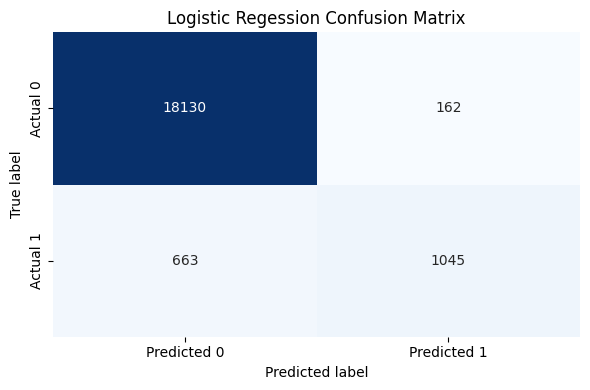

In [ ]:
# Menghitung matriks kebingungan
logreg_cm = confusion_matrix(y_test, y_pred_lr)

# Plotting confusion matrix heatmap untuk Logreg
plt.figure(figsize=(6, 4))
sns.heatmap(logreg_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Logistic Regession Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

#Accuracy Yang Paling Baik

In [ ]:
# Cetak akurasi dari berbagai model
print("RandomForestClassifier Accuracy:", accuracy_rf)
print("KNN Accuracy:", accuracy_knn)
print("Decision Tree Model Accuracy:", accuracy_dt)
print("Multinomial Naive Bayes Model Accuracy:", accuracy_nb)
print("Logistic Regression Accuracy:", accuracy_lr)

# Menghitung model dengan akurasi paling mendekati 1
accuracies = {
    'Random Forest': accuracy_rf,
    'KNN': accuracy_knn,
    'Decision Tree': accuracy_dt,
    'Multinomial Naive Bayes': accuracy_nb,
    'Logistic Regression': accuracy_lr,
}

# Model dengan akurasi terbesar
best_model = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model]

print("\nModel with accuracy closest to 1:")
print(f"{best_model} with accuracy {best_accuracy}")

# Model dengan akurasi terkecil
worst_model = min(accuracies, key=accuracies.get)
worst_accuracy = accuracies[worst_model]

print("\nModel with smallest accuracy:")
print(f"{worst_model} with accuracy {worst_accuracy}")

RandomForestClassifier Accuracy: 0.97225
KNN Accuracy: 0.9525
Decision Tree Model Accuracy: 0.972
Multinomial Naive Bayes Model Accuracy: 0.90475
Logistic Regression Accuracy: 0.95875

Model with accuracy closest to 1:
Random Forest with accuracy 0.97225

Model with smallest accuracy:
Multinomial Naive Bayes with accuracy 0.90475


#Cek Overfitting


In [ ]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':GaussianNB()
}

# Loop untuk melatih setiap model dan mengecek overfitting
for name, model in models.items():
    model.fit(X_train, y_train)  # Latih model

    # Hitung akurasi pada data training dan test
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))

    # Tampilkan hasil
    print(f"\n{name}")
    print(f"Akurasi Training: {train_accuracy:.2f}")
    print(f"Akurasi Test: {test_accuracy:.2f}")

    # Cek overfitting
    if train_accuracy - test_accuracy > 0.1:  # Threshold 10%
        print("Model kemungkinan overfitting.")
    else:
        print("Model tidak overfitting.")


Random Forest
Akurasi Training: 1.00
Akurasi Test: 0.97
Model tidak overfitting.

K-Nearest Neighbors
Akurasi Training: 0.96
Akurasi Test: 0.95
Model tidak overfitting.

Decision Tree
Akurasi Training: 1.00
Akurasi Test: 0.95
Model tidak overfitting.

Logistic Regression
Akurasi Training: 0.96
Akurasi Test: 0.96
Model tidak overfitting.

Naive Bayes
Akurasi Training: 0.90
Akurasi Test: 0.90
Model tidak overfitting.


#Deployment

In [ ]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Simpan model ke dalam file
joblib.dump(model, 'diabetes_model.pkl')

model = joblib.load('diabetes_model.pkl')

In [ ]:
# Data baru dengan encoding numerik
data_baru = [[2, 25, 1, 2, 1, 30.00, 7.6, 150]]

# Pastikan urutan kolom sesuai dengan model
data_baru_df = pd.DataFrame(data_baru, columns=[
    'gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level'
])

# Prediksi
prediksi = model.predict(data_baru_df)

# Output hasil prediksi
print("Hasil prediksi:", "Diabetes" if prediksi[0] == 1 else "Tidak Diabetes")


Hasil prediksi: Diabetes


In [ ]:
# prompt: download file diabates_model.pkl

files.download('diabetes_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>